In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from astropy.visualization import hist
from scipy.stats import norm
import scipy

In [191]:
mu_true = 1
sigma_true = 0.2
np.random.seed(10)
distG = norm(loc = mu_true, scale=sigma_true) #gaussian dist

[]

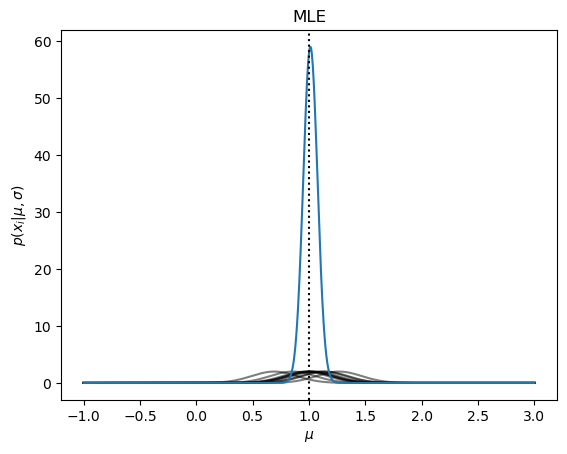

In [192]:
N = 10
data = distG.rvs(N) #random draws from gaussian dist
for i in data:
    # Scan across 1000 possible mu values
    mu_proposed = np.linspace(mu_true-2,mu_true+2,1000)
    
    # compute L for each possible mu
    L_scan = []
    for mu in mu_proposed:
        L_temp = norm.pdf(i, loc=mu, scale=sigma_true) # gives you the prob. density
        L_temp = np.prod(L_temp) # prod over all data points
        L_scan.append(L_temp)
        
    L_scan = np.array(L_scan)
    if i == data[0] : L_tot = L_scan
    else : L_tot = L_tot*L_scan
        
    plt.plot(mu_proposed,L_scan,c='k',alpha=0.5)


plt.plot(mu_proposed,L_tot)
plt.axvline(mu_true,c='black',ls='dotted')
plt.title('MLE')
plt.xlabel(r'$\mu$')
plt.ylabel(r'$p(x_i|\mu, \sigma)$')
plt.plot()

MLE mu: 1.0100, true mu: 1.0000


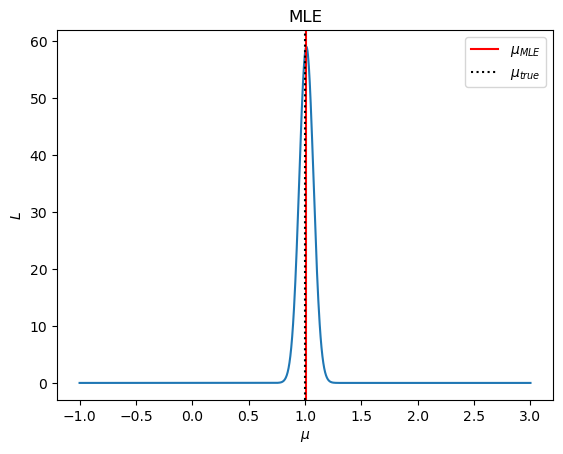

In [193]:
plt.plot(mu_proposed,L_tot)
    
findmax = mu_proposed[np.argmax(L_tot)]
print('MLE mu: %.4f, true mu: %.4f' % (findmax, mu_true))
plt.axvline(findmax,c='red',label=r'$\mu_{MLE}$')
    
plt.axvline(mu_true,c='black',ls='dotted',label=r'$\mu_{true}$')

plt.title('MLE')
plt.xlabel(r'$\mu$')
plt.ylabel(r'$L$')
plt.legend();

In [194]:
diff = np.diff(np.log(L_tot), n=2)
delta_mu = (mu_proposed[1]-mu_proposed[0]) #delta viene dall'asse di mu testate
sigma_f = 1/np.sqrt(-diff[np.argmax(L_tot)]/delta_mu**2)
print("Fisher information matrix error on estimated mean is", sigma_f)


sigma_ml = sigma_true/np.sqrt(N)
print("Fisher information matrix error", sigma_ml)

Fisher information matrix error on estimated mean is 0.06324555320336836
Fisher information matrix error 0.06324555320336758


[]

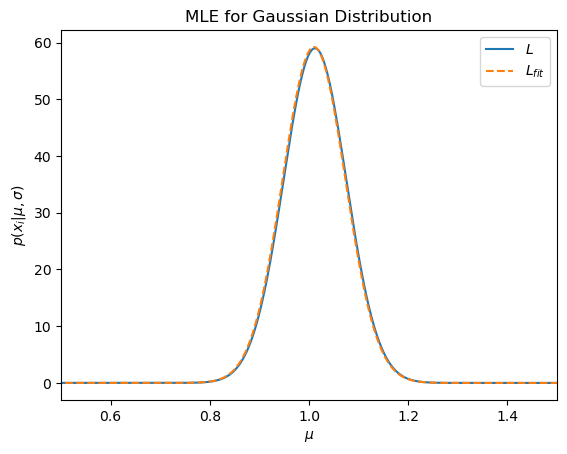

In [206]:
plt.plot(mu_proposed,L_tot,label=r'$L$')

L_fit = norm.pdf(mu_proposed,loc=findmax,scale=sigma_ml) / 0.1065 # la normalizzazione è scelta ad hoc
plt.plot(mu_proposed,L_fit,linestyle='--',label=r'$L_{fit}$')

plt.xlim(mu_true-0.5,mu_true+0.5)
plt.xlabel('$\mu$') #Leave out or adjust if no latex
plt.ylabel(r'$p(x_i|\mu,\sigma)$') #Leave out or adjust if no latex
plt.title('MLE for Gaussian Distribution')
plt.legend()
plt.plot()

In [ ]:
#with logs

1.011011011011011


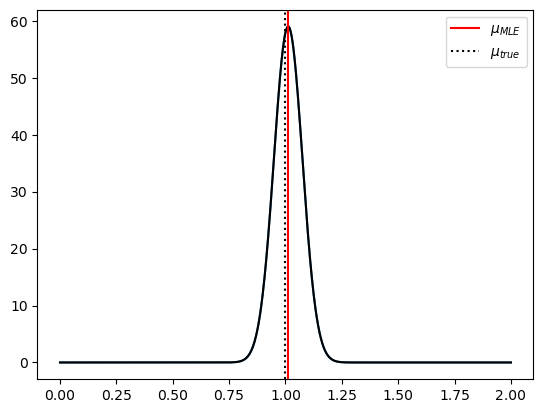

In [207]:
#data = distG.rvs(N)

mu_proposed = np.linspace(0,2,1000)
ll = np.zeros(1000)
# compute the lnL for each possible mu.
lnL_scan = []
for mu in mu_proposed:
    lnL_temp = norm.logpdf(data, loc=mu, scale=sigma_true) 
    lnL_temp = np.sum(lnL_temp) 
    lnL_scan.append( lnL_temp )
    
# convert to numpy array
lnL_scan = np.array(lnL_scan)

# mu_proposed that maximizes the lnL.
plt.plot(mu_proposed,np.e**lnL_scan)

findmax = mu_proposed[np.argmax(lnL_scan)]
plt.axvline(findmax,c='k',alpha=0.2,linestyle='--')
if i == data[0]: ll = lnL_scan
else: ll = ll+lnL_scan

plt.plot(mu_proposed,np.e**ll,c='k')

findmax = mu_proposed[np.argmax(ll)]
print(findmax)
plt.axvline(findmax,c='red', label=r'$\mu_{MLE}$')
plt.axvline(1,c='black',ls='dotted', label=r'$\mu_{true}$')
plt.legend();

In [208]:
diff = np.diff(ll, n=2)
delta_mu = (mu_proposed[1]-mu_proposed[0]) #delta viene dall'asse di mu testate
sigma_f = 1/np.sqrt(-diff[np.argmax(ll)]/delta_mu**2)
print("Fisher information matrix error on estimated mean is", sigma_f)


sigma_ml = sigma_true/np.sqrt(N)
print("Fisher information matrix error", sigma_ml)

Fisher information matrix error on estimated mean is 0.063245553203347
Fisher information matrix error 0.06324555320336758


In [180]:
#Part 3: the ten samples are taken on different nights --> N different sigmas 

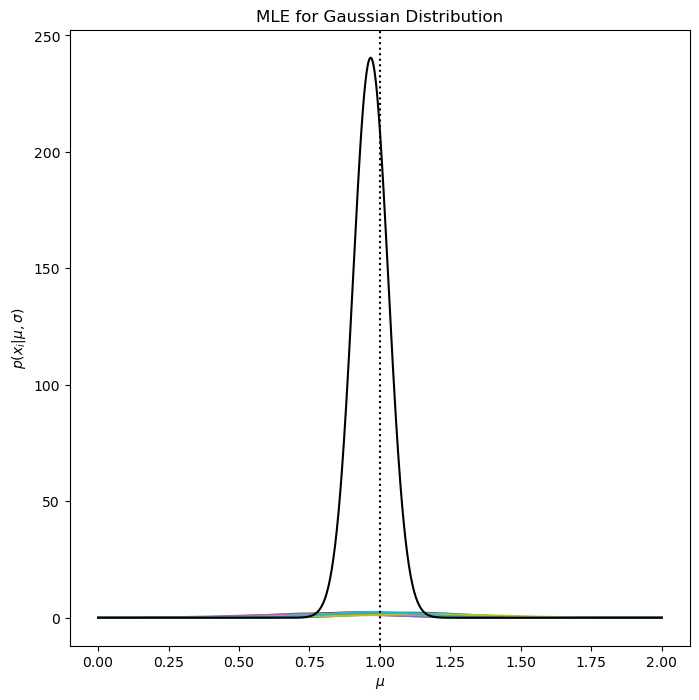

In [210]:
N = 10
mu = 1
sigma = norm(0.2,0.05).rvs(N)
sample = np.concatenate([norm(mu,s).rvs(1) for s in sigma])

xgrid = np.linspace(0,2,1000)

#la griglia è di valori a cui calcolare la pdf, le gaussiane sono centrate sui valori estratti prima
Ls = np.array([norm.pdf(xgrid,loc=s,scale=ss) for s,ss in zip(sample,sigma)])
L = np.prod(Ls,axis=0)

fig, ax = plt.subplots(figsize=(8, 8))                     
for thisL in Ls:
    plt.plot(xgrid, thisL)
    
plt.plot(xgrid, L, c='k')


plt.axvline(mu_true,c='black',ls='dotted')

plt.xlabel('$\mu$') #Leave out or adjust if no latex
plt.ylabel(r'$p(x_i|\mu,\sigma)$') #Leave out or adjust if no latex
plt.title('MLE for Gaussian Distribution');

In [182]:
findmax = np.argmax(L)

MLest = np.average(sample,weights=1/sigma**2)
print("The mean is my estimator", MLest)

The mean is my estimator 0.9712433788154052


In [183]:
diff = np.diff(np.log(L), n=2)
delta_mu = (xgrid[1]-xgrid[0]) #delta viene dall'asse di mu testate
sigma_f = 1/np.sqrt(-diff[np.argmax(L)]/delta_mu**2)
print("Fisher information matrix error on estimated mean is", sigma_f)


MLEsigma = np.sum(sigma**-2)**-0.5
print("Fisher matrix error", MLEsigma)

Fisher information matrix error on estimated mean is 0.06091241942163394
Fisher matrix error 0.0609124194216488
